In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve
from sklearn.calibration import CalibratedClassifierCV

In [2]:
database='postgres'
user='postgres'
password='postgres'
host='localhost'
port='5433'

engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")
query = "select * from fct__german_credit_wide"

data = pd.read_sql(query, engine)
data.drop(columns='id',inplace=True)

### **Dataset Feature Documentation**

#### Primary Key
- **id**: Unique identifier for each record.

#### Target Variable
- **risk**: Binary or categorical indicator representing the credit risk level of the applicant.

#### General Profile
- **age**: Age of the applicant (numeric).
- **sex**: Gender of the applicant (categorical).

#### Credit Exposure
- **duration_months**: Loan duration in months.
- **credit_amount**: Total credit amount requested.
- **log_credit_amount**: Log-transformed credit amount to reduce skewness.
- **credit_exposure**: Derived metric representing total exposure to credit.
- **credit_per_age_year**: Ratio of credit amount to applicant’s age.
- **monthly_payment_estimate**: Estimated monthly loan repayment.
- **loan_term_tier**: Categorized loan duration bucket (categorical).

#### Liquidity
- **savings_score**: Numeric score representing savings account status.
- **checking_score**: Numeric score representing checking account status.
- **total_liquidity_score**: Combined liquidity indicator.
- **has_no_savings_info**: Indicator for missing savings account information (binary).
- **has_no_checking_info**: Indicator for missing checking account information (binary).
- **saving_accounts**: Savings account category (categorical).
- **checking_account**: Checking account category (categorical).

#### Profile Risk
- **job_skill_level**: Ordinal indicator of the applicant’s job skill level.
- **housing_stability_score**: Score reflecting housing stability.
- **stable_profile_flag**: Indicator for a stable applicant profile (binary).
- **high_risk_profile_flag**: Indicator for a high-risk applicant profile (binary).
- **housing**: Housing type (categorical).
- **purpose**: Purpose of the loan (categorical).
- **purpose_risk_group**: Risk grouping based on loan purpose (categorical).

#### Notes
- Categorical variables should be encoded prior to modeling.
- Derived variables may introduce multicollinearity and should be evaluated (e.g., using variance inflation factor).
- Binary indicators are expected to take values of 0 or 1.

#### **Multicollinearity Considerations**

The following combinations of variables should not be included together in the same model, as they may introduce multicollinearity due to redundancy or deterministic relationships:

1. **`purpose`** and **`purpose_risk_group`**  
2. **`housing`** and **`housing_stability_score`**  
3. **`job_skill_level`**, **`housing`**, and **`stable_profile_flag`**  
4. **`saving_accounts`** and **`savings_score`**  
5. **`checking_account`** and **`checking_score`**  
6. **`saving_accounts`**, **`checking_score`**, and **`total_liquidity_score`**  
7. **`log_credit_amount`** and **`credit_amount`**  
8. **`credit_amount`**, **`duration_months`**, and **`credit_exposure`**  
9. **`credit_amount`**, **`age`**, and **`credit_per_age_year`**  
10. **`credit_amount`**, **`duration_months`**, and **`monthly_payment_estimate`**  
11. **`duration_months`** and **`loan_term_tier`**

#### Notes
- These combinations include variables that are either directly derived from one another or capture overlapping information.
- Including them simultaneously may lead to unstable model estimates and inflated variance.
- It is recommended to select one representative variable from each group based on interpretability or predictive performance.

### **Relevant Concepts**

#### Train / Test Split
We train 80% of the data and test model performance with the other 20%.<br>
This is highly relevant in order to check for overfitting in our model.

#### K-Fold Cross Validation
We divide our data into five folds. In each iteration, we train our model with four folds and test with one:<br>
<i><br>
    [**test** | train | train | train | train]<br>
    [train | **test** | train | train | train]<br>
    [train | train | **test** | train | train]<br>
    [train | train | train | **test** | train]<br>
    [train | train | train | train | **test**]<br>
</i><br>
We evaluate prediction accuracy for each with AUC-ROC and average them out to evaluate overall model performance.

#### L1 Regularization (LASSO)

This technique adds the absolute value of each feature's weight to the cost function:
$$
\text{Cost} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 
+ \lambda \sum_{i=1}^{m} |w_i|
$$
This is highly useful for feature selection, as it can reduce reduntant coefficients to zero.<br>
Regularization also helps avoid overfitting, as our loss function penalizes model complexity.

#### AUC and ROC Curve

The ROC curve plots the trade off between
- The True Positive Rate: $TRP = \dfrac{TP}{TP + FN}$ ----- y-axis
- The False Positive Rate: $FPR = \dfrac{FP}{TN + FP}$ ----- x-axis

for each threshold.

AUC-ROC (Area Under the ROC Curve) gives us the model's overall performance across all model thresholds.<br>
Unlike accuracy, precision, or F1-score, AUC-ROC allows us to evaluate each model without having to specify a given theshold.

#### Kolmogorov–Smirnov Statistic (KS)

Separate defaulters and non-defaulters into seperate distributions. The KS statistic is the maximum distance between the empirical distribution functions (EDF), that is, between the estimated Cumulative Distribution Function (CDF).

- KS < 0.20 -> week model
- KS 0.20 - 0.40 -> acceptable
- KS 0.50 - 0.70 -> strong model

#### Model Calibration

Once estimated probabilities are obtained, we build another logistic regression to determine new probabilities: minimize distance between the probabilities and observed default or non-default.

### Function Definitions

In [3]:
def plot_corr(df):
    corr = df.drop(columns='risk').corr()
    
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

def scale(df):
    numeric = list(df.select_dtypes(include=['number']).columns)
    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(df[numeric])
    df_scaled = df.copy()
    df_scaled[numeric] = numeric_scaled
    return df_scaled

def one_hot_encode(df):
    non_numeric = list(df.select_dtypes(exclude=['number']).columns)
    df_encoded = pd.get_dummies(df, columns=non_numeric, drop_first=True).astype(int)
    print('Non-numeric columns:')
    for _ in non_numeric:
        print('   ',_)
    print('Encoded data shape: ',df_encoded.shape)
    return df_encoded

### Check All Features for Correlation

In [4]:
data.columns

Index(['risk', 'age', 'sex', 'duration_months', 'credit_amount',
       'log_credit_amount', 'credit_exposure', 'credit_per_age_year',
       'monthly_payment_estimate', 'loan_term_tier', 'savings_score',
       'checking_score', 'total_liquidity_score', 'has_no_savings_info',
       'has_no_checking_info', 'saving_accounts', 'checking_account',
       'job_skill_level', 'housing_stability_score', 'stable_profile_flag',
       'high_risk_profile_flag', 'housing', 'purpose', 'purpose_risk_group'],
      dtype='str')

In [5]:
data_encoded = one_hot_encode(data)

Non-numeric columns:
    sex
    loan_term_tier
    saving_accounts
    checking_account
    housing
    purpose
    purpose_risk_group
Encoded data shape:  (1000, 39)


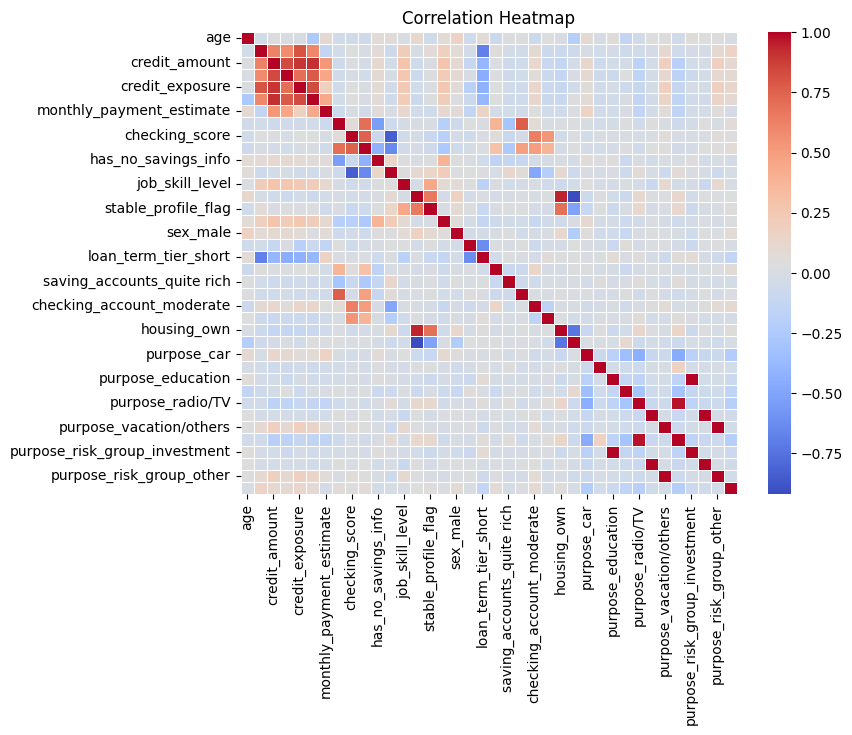

In [6]:
plot_corr(data_encoded)

### Logistic Regression with Base Parameters

Non-numeric columns:
    sex
    saving_accounts
    checking_account
    housing
    purpose
Encoded data shape:  (1000, 20)


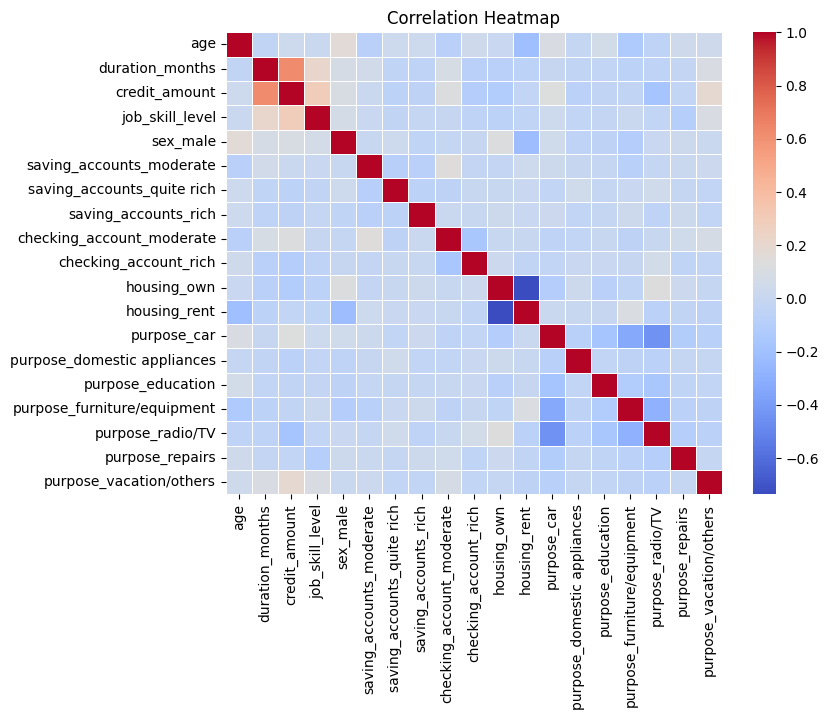

In [7]:
df = data[[
    'risk',
    'age',
    'sex',
    'duration_months',
    'credit_amount', # can be replaced by log_credit_amount
    'saving_accounts',
    'checking_account',
    'job_skill_level',
    'housing',
    'purpose' 
]].copy()

df_encoded = one_hot_encode(df)
plot_corr(df_encoded)

In [8]:
X = df_encoded.copy()
X.drop(columns='risk',inplace=True)
X = add_constant(X)
X = X.dropna()
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                        Feature        VIF
0                         const  60.823772
1                           age   1.165216
2               duration_months   1.739868
3                 credit_amount   1.878751
4               job_skill_level   1.117420
5                      sex_male   1.099450
6      saving_accounts_moderate   1.053962
7    saving_accounts_quite rich   1.024872
8          saving_accounts_rich   1.025680
9     checking_account_moderate   1.086895
10        checking_account_rich   1.041197
11                  housing_own   2.534271
12                 housing_rent   2.649903
13                  purpose_car   3.134030
14  purpose_domestic appliances   1.135099
15            purpose_education   1.594923
16  purpose_furniture/equipment   2.512388
17             purpose_radio/TV   2.946657
18              purpose_repairs   1.223316
19      purpose_vacation/others   1.155531


In [9]:
X = df.copy()
X.drop(columns='risk',inplace=True)
X = scale(X)
X = one_hot_encode(X)

y = df['risk']

Non-numeric columns:
    sex
    saving_accounts
    checking_account
    housing
    purpose
Encoded data shape:  (1000, 19)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
feature_cols = X_train.columns.tolist()
print(feature_cols)

['age', 'duration_months', 'credit_amount', 'job_skill_level', 'sex_male', 'saving_accounts_moderate', 'saving_accounts_quite rich', 'saving_accounts_rich', 'checking_account_moderate', 'checking_account_rich', 'housing_own', 'housing_rent', 'purpose_car', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_radio/TV', 'purpose_repairs', 'purpose_vacation/others']


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegressionCV(
    l1_ratios=(1,),
    solver='saga',
    cv=cv,
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=1000,
    use_legacy_attributes=False
)

model.fit(X_train, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(1,)"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

good = y_prob[y_test == 0]
bad  = y_prob[y_test == 1]
ks_stat, _ = ks_2samp(good, bad)

print(f"AUC: {auc:.3f}")
print(f"KS:  {ks_stat:.3f}")

AUC: 0.636
KS:  0.212


### Logistic Regression with Base Parameters - Log Credit Amount

In [109]:
df = data[[
    'risk',
    'age',
    'sex',
    'duration_months',
    'log_credit_amount', # can be replaced by log_credit_amount
    'saving_accounts',
    'checking_account',
    'job_skill_level',
    'housing',
    'purpose' 
]].copy()

In [110]:
X = df.copy()
X.drop(columns='risk',inplace=True)
X = scale(X)
X = one_hot_encode(X)

y = df['risk']

Non-numeric columns:
    sex
    saving_accounts
    checking_account
    housing
    purpose
Encoded data shape:  (1000, 19)


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [112]:
feature_cols = X_train.columns.tolist()
print(feature_cols)

['age', 'duration_months', 'log_credit_amount', 'job_skill_level', 'sex_male', 'saving_accounts_moderate', 'saving_accounts_quite rich', 'saving_accounts_rich', 'checking_account_moderate', 'checking_account_rich', 'housing_own', 'housing_rent', 'purpose_car', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_radio/TV', 'purpose_repairs', 'purpose_vacation/others']


In [114]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegressionCV(
    l1_ratios=(1,),
    solver='saga',
    cv=cv,
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=1000,
    use_legacy_attributes=False
)

model.fit(X_train, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(1,)"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-

In [115]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

good = y_prob[y_test == 0]
bad  = y_prob[y_test == 1]
ks_stat, _ = ks_2samp(good, bad)

print(f"AUC: {auc:.3f}")
print(f"KS:  {ks_stat:.3f}")

AUC: 0.634
KS:  0.217


### Logistic Regression with Extracted Features

In [116]:
df = data[[
    'risk',
    'sex',
    'credit_exposure',
    'loan_term_tier',
    'savings_score',
    'checking_score',
    'has_no_savings_info',
    'has_no_checking_info',
    'job_skill_level',
    'housing_stability_score',
    'purpose_risk_group'
]].copy()

In [117]:
X = df.copy()
X.drop(columns='risk',inplace=True)
X = scale(X)
X = one_hot_encode(X)

y = df['risk']

Non-numeric columns:
    sex
    loan_term_tier
    purpose_risk_group
Encoded data shape:  (1000, 15)


In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [119]:
feature_cols = X_train.columns.tolist()
print(feature_cols)

['credit_exposure', 'savings_score', 'checking_score', 'has_no_savings_info', 'has_no_checking_info', 'job_skill_level', 'housing_stability_score', 'sex_male', 'loan_term_tier_medium', 'loan_term_tier_short', 'purpose_risk_group_consumer', 'purpose_risk_group_investment', 'purpose_risk_group_maintenance', 'purpose_risk_group_other', 'purpose_risk_group_productive']


In [120]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegressionCV(
    l1_ratios=(1,),
    solver='saga',
    cv=cv,
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=1000,
    use_legacy_attributes=False
)

model.fit(X_train, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(1,)"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-

In [121]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

good = y_prob[y_test == 0]
bad  = y_prob[y_test == 1]
ks_stat, _ = ks_2samp(good, bad)

print(f"AUC: {auc:.3f}")
print(f"KS:  {ks_stat:.3f}")

AUC: 0.765
KS:  0.455


In [26]:
coefs = pd.Series(
    model.coef_[0],
    index=feature_cols
).sort_values()

odds_ratios = np.exp(coefs)
print(odds_ratios.sort_values())

purpose_risk_group_investment     0.518121
purpose_risk_group_maintenance    0.621974
credit_exposure                   0.790117
purpose_risk_group_productive     0.892548
purpose_risk_group_other          0.893095
job_skill_level                   1.053910
savings_score                     1.276768
housing_stability_score           1.369539
checking_score                    1.466995
loan_term_tier_medium             1.469442
sex_male                          1.500968
purpose_risk_group_consumer       1.507241
has_no_savings_info               1.591140
loan_term_tier_short              2.224870
has_no_checking_info              9.485407
dtype: float64


In [27]:
vif = pd.DataFrame()
vif['feature'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) 
              for i in range(X_train.shape[1])]
print(vif.sort_values('VIF', ascending=False))

                           feature       VIF
4             has_no_checking_info  5.445856
2                   checking_score  3.238211
7                         sex_male  2.621181
8            loan_term_tier_medium  2.279288
9             loan_term_tier_short  2.273519
3              has_no_savings_info  1.791238
10     purpose_risk_group_consumer  1.546633
1                    savings_score  1.451308
0                  credit_exposure  1.294449
14   purpose_risk_group_productive  1.226226
6          housing_stability_score  1.210180
5                  job_skill_level  1.125726
11   purpose_risk_group_investment  1.106688
13        purpose_risk_group_other  1.068971
12  purpose_risk_group_maintenance  1.065763


In [28]:
df.groupby('risk')['credit_exposure'].mean()

risk
0    123269.170000
1     75215.472857
Name: credit_exposure, dtype: float64

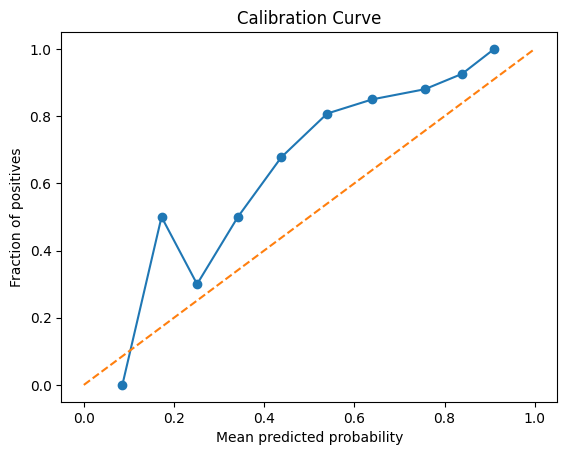

In [29]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(mean_predicted_value, fraction_of_positives, marker='o')
plt.plot([0,1], [0,1], linestyle='--')  # perfect calibration line
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.show()

In [30]:
y_pred = (y_prob >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[47 13]
 [49 91]]
              precision    recall  f1-score   support

           0       0.49      0.78      0.60        60
           1       0.88      0.65      0.75       140

    accuracy                           0.69       200
   macro avg       0.68      0.72      0.67       200
weighted avg       0.76      0.69      0.70       200



In [31]:
y_pred_strict = (y_prob >= 0.3).astype(int)

print(confusion_matrix(y_test, y_pred_strict))
print(classification_report(y_test, y_pred_strict))

[[ 23  37]
 [ 14 126]]
              precision    recall  f1-score   support

           0       0.62      0.38      0.47        60
           1       0.77      0.90      0.83       140

    accuracy                           0.74       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.74      0.72       200



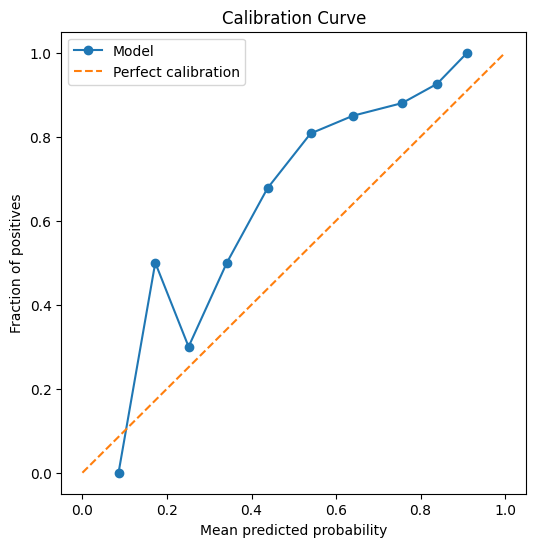

In [32]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [33]:
calibrated_model = CalibratedClassifierCV(model, method='sigmoid')
calibrated_model.fit(X_train, y_train)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Recheck metrics
auc_cal = roc_auc_score(y_test, y_prob_cal)
good_cal = y_prob_cal[y_test == 0]
bad_cal  = y_prob_cal[y_test == 1]
ks_cal, _ = ks_2samp(good_cal, bad_cal)

print(f"AUC calibrated: {auc_cal:.3f}")
print(f"KS calibrated:  {ks_cal:.3f}")

AUC calibrated: 0.769
KS calibrated:  0.476


In [34]:
y_prob_cal

array([0.73185228, 0.68041379, 0.51088223, 0.84344824, 0.57322083,
       0.81253439, 0.91483732, 0.62330899, 0.39419826, 0.90792133,
       0.6292035 , 0.83326051, 0.5288134 , 0.55868218, 0.78161885,
       0.6750347 , 0.69112075, 0.90655116, 0.91483732, 0.73540988,
       0.70713172, 0.86243624, 0.69112075, 0.93248748, 0.87228534,
       0.70418352, 0.69276289, 0.4782593 , 0.89572248, 0.37455171,
       0.85697323, 0.69634458, 0.6826546 , 0.85832381, 0.40151543,
       0.41627936, 0.69654324, 0.6778391 , 0.80566767, 0.54676854,
       0.75348453, 0.8270869 , 0.91753542, 0.53207796, 0.39419826,
       0.21744159, 0.73298293, 0.81753256, 0.31499089, 0.86177708,
       0.83658822, 0.47158994, 0.62330899, 0.8774665 , 0.8518077 ,
       0.89572248, 0.88853742, 0.68400681, 0.94278772, 0.72721227,
       0.53046847, 0.75006869, 0.89572248, 0.92222459, 0.46652101,
       0.94076487, 0.91806328, 0.76706892, 0.53207796, 0.89262948,
       0.89262948, 0.6208914 , 0.71852863, 0.61601348, 0.92490

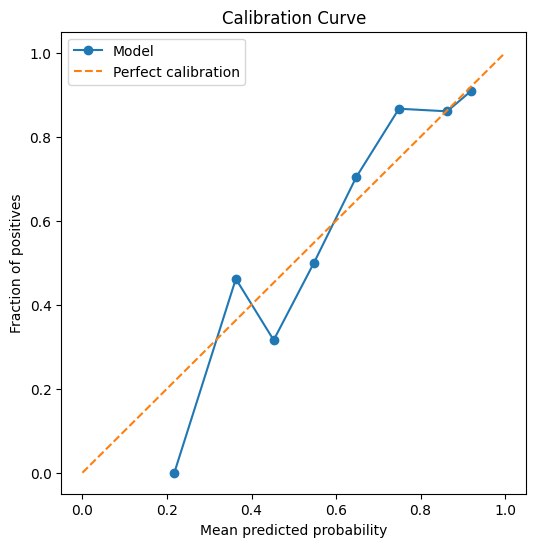

In [35]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_cal, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [36]:
y_pred_cal = (y_prob_cal >= 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_cal))
print(classification_report(y_test, y_pred_cal))

[[  1  59]
 [  0 140]]
              precision    recall  f1-score   support

           0       1.00      0.02      0.03        60
           1       0.70      1.00      0.83       140

    accuracy                           0.70       200
   macro avg       0.85      0.51      0.43       200
weighted avg       0.79      0.70      0.59       200



In [37]:
y_pred_cal = (y_prob_cal >= 0.4).astype(int)
print(confusion_matrix(y_test, y_pred_cal))
print(classification_report(y_test, y_pred_cal))

[[  8  52]
 [  6 134]]
              precision    recall  f1-score   support

           0       0.57      0.13      0.22        60
           1       0.72      0.96      0.82       140

    accuracy                           0.71       200
   macro avg       0.65      0.55      0.52       200
weighted avg       0.68      0.71      0.64       200



In [38]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cal)

for thresh, fp, tp in zip(thresholds, fpr, tpr):
    tn = int((1-fp) * 60)
    fn = int((1-tp) * 140)
    print(f"Threshold: {thresh:.2f}  Bad approved: {fn}  Good rejected: {60-tn}")

Threshold: inf  Bad approved: 140  Good rejected: 0
Threshold: 0.96  Bad approved: 139  Good rejected: 0
Threshold: 0.92  Bad approved: 131  Good rejected: 0
Threshold: 0.92  Bad approved: 131  Good rejected: 1
Threshold: 0.92  Bad approved: 130  Good rejected: 1
Threshold: 0.91  Bad approved: 127  Good rejected: 1
Threshold: 0.91  Bad approved: 126  Good rejected: 1
Threshold: 0.91  Bad approved: 126  Good rejected: 2
Threshold: 0.91  Bad approved: 125  Good rejected: 2
Threshold: 0.90  Bad approved: 122  Good rejected: 2
Threshold: 0.90  Bad approved: 120  Good rejected: 2
Threshold: 0.90  Bad approved: 119  Good rejected: 2
Threshold: 0.90  Bad approved: 115  Good rejected: 2
Threshold: 0.89  Bad approved: 114  Good rejected: 2
Threshold: 0.89  Bad approved: 110  Good rejected: 2
Threshold: 0.88  Bad approved: 104  Good rejected: 2
Threshold: 0.87  Bad approved: 104  Good rejected: 3
Threshold: 0.87  Bad approved: 102  Good rejected: 3
Threshold: 0.87  Bad approved: 98  Good rejecte

In [39]:
y_pred_final = (y_prob_cal >= 0.59).astype(int)
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[ 35  25]
 [ 23 117]]
              precision    recall  f1-score   support

           0       0.60      0.58      0.59        60
           1       0.82      0.84      0.83       140

    accuracy                           0.76       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.76      0.76      0.76       200



In [61]:
sum(((y_prob_cal >= 0.59).astype(int) == y_test)==0)/sum(y_test==0)

0.8

In [69]:
y_prob_cal >= 0.59

array([ True,  True, False,  True, False,  True,  True,  True, False,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True,  True, False, False,
        True,  True,  True, False,  True,  True,  True, False, False,
       False,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False, False,
       False,  True, False,  True,  True, False,  True,  True,  True,
       False,  True, False,  True,  True, False, False, False,  True,
       False,  True, False,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True, False,
        True,  True,

#### Sources

- Geeks For Geeks. *Kolmogorov-Smirnov Test (KS Test)*<br>
  [https://www.geeksforgeeks.org/machine-learning/kolmogorov-smirnov-test-ks-test/](https://www.geeksforgeeks.org/machine-learning/kolmogorov-smirnov-test-ks-test/)
- Towards Data Science. *The Kolmogorov–Smirnov Statistic, Explained: Measuring Model Power in Credit Risk Modeling*
  [https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/](https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/)